# ROI Interpretation Pipeline - Workshop Demo

This notebook demonstrates a three-stage AI pipeline for analyzing kidney tissue regions.

## What You'll See
- **VisualProfiler**: AI analyzes microscopy images to identify tissue structures
- **OmicsProfiler**: AI analyzes molecular biomarker data
- **OmicsInterpreter**: AI combines both sources for final interpretation

## How to Use
1. **Set your API key** in the cell below (if running in real mode)
2. **Choose your mode**: Simulation (fast, cached) or Real (full pipeline)
3. **Run all cells**: Runtime → Run All
4. **Explore the results**: Evaluation metrics and visualizations

## Step 1: Your Configuration

In [1]:
# ============================================================
# YOUR CONFIGURATION
# ============================================================

# Enter your API key here (for real mode only)
API_KEY = "***REMOVED***"

# Choose your model
# Options: gemini-3.1-pro-preview, gemini-3.1-flash-lite-preview, gemini-2.5-flash-lite
MODEL_NAME = "gemini-3.1-flash-lite-preview"

# Run mode
# True = fast demo (uses cached results, no API calls)
# False = full pipeline (requires API key, runs LLM analysis)
SIMULATE = True

# ============================================================
# Display configuration
# ============================================================
print("Configuration ready!")
print(f"  Model: {MODEL_NAME}")
print(f"  Mode: {'Demo (cached results)' if SIMULATE else 'Full Pipeline (LLM calls)'}")
if not SIMULATE:
    print(f"  API Key: {'Set' if API_KEY != 'your-api-key-here' else 'NOT SET - please add your key'}")

Configuration ready!
  Model: gemini-3.1-flash-lite-preview
  Mode: Demo (cached results)


## Step 2: Load Pipeline Components

In [2]:
# Import helper module and load configuration
import helper

# Load all pipeline configurations and functions
config = helper.load_config("./config.yaml")

print("Pipeline loaded successfully!")
print(f"  Data root: {config['data_root']}")
print(f"  Evaluation classes: {len(config['classes'])} tissue types")

ModuleNotFoundError: No module named 'src.data.data_models'

## Step 3: Load Data

In [8]:
# Load ROI data and results
# - In simulation mode: loads cached results from previous runs
# - In real mode: loads ROI registry for processing
manifest, visual_results, omics_results, interp_results = helper.load_data(
    config, simulate=SIMULATE
)

print(f"Data loaded successfully!")
print(f"  Total ROIs: {len(manifest)}")
print(f"  Regions: {len(set(r['region_id'] for r in manifest))}")

Loaded 50 ROIs from simulation cache
Data loaded successfully!
  Total ROIs: 50
  Regions: 3


## Step 4: Initialize Model (Real Mode Only)

In [9]:
if not SIMULATE:
    # Check if API key is set
    if API_KEY == "your-api-key-here":
        print("⚠️  WARNING: Please set your API_KEY in Step 1")
    else:
        model = helper.initialize_model(MODEL_NAME, API_KEY, config)
        print(f"Model initialized: {MODEL_NAME}")
        print("Ready to run pipeline!")
else:
    print("Using cached results (no model needed in simulation mode)")

Using cached results (no model needed in simulation mode)


## Step 5: Run Pipeline (Real Mode Only)

In [10]:
if not SIMULATE and API_KEY != "your-api-key-here":
    # Run the complete three-stage pipeline
    # This may take several minutes depending on the number of ROIs
    visual_results, omics_results, interp_results = helper.run_pipeline(
        manifest, model, config
    )
    print("\nPipeline execution complete!")
elif SIMULATE:
    print("Using cached results from simulation mode")
    print("(Set SIMULATE=False in Step 1 to run the full pipeline)")
else:
    print("⚠️  Please set your API_KEY in Step 1 to run the pipeline")

Using cached results from simulation mode
(Set SIMULATE=False in Step 1 to run the full pipeline)


## Step 6: View Results


EVALUATING THREE-STAGE PIPELINE

EVALUATION: VisualProfiler

📊 VisualProfiler Results:
  Accuracy: 0.8600
  Precision (Macro): 0.8408
  Recall (Macro): 0.8600
  F1 Score (Macro): 0.8478

📈 Per-Class Metrics (Top-1):
Class                | Precision | Recall   | F1 Score | Support
----------------------------------------------------------------------
  Proximal tubules     | 0.786     | 0.733    | 0.759    | 15
  Distal tubules       | 0.818     | 0.900    | 0.857    | 10
  Glomeruli            | 1.000     | 0.917    | 0.957    | 12
  Blood vessel         | 1.000     | 1.000    | 1.000    | 9
  Interstitium         | 0.600     | 0.750    | 0.667    | 4

EVALUATION: OmicsProfiler

📊 OmicsProfiler Results:
  Accuracy: 0.9000
  Precision (Macro): 0.8617
  Recall (Macro): 0.8722
  F1 Score (Macro): 0.8617

📈 Per-Class Metrics (Top-1):
Class                | Precision | Recall   | F1 Score | Support
----------------------------------------------------------------------
  Proximal tubules   

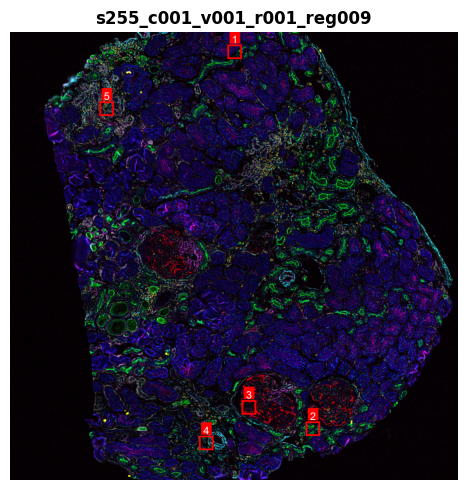





REGION: s255_c001_v001_r001_reg019
Selected 5 ROIs (one per tissue type)


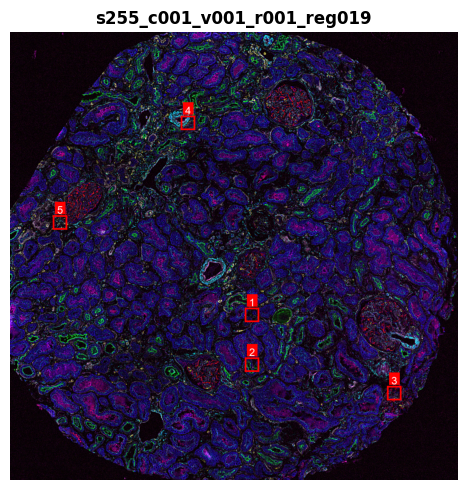





REGION: s255_c001_v001_r001_reg023
Selected 4 ROIs (one per tissue type)


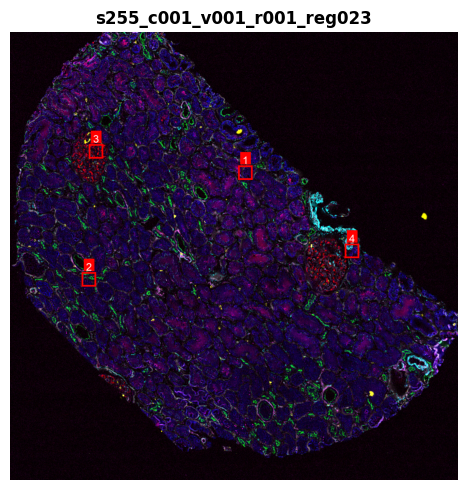





✅ Visualization complete!

✅ PIPELINE COMPLETE


In [11]:
# Display evaluation metrics and visualization
helper.show_results(
    manifest, visual_results, omics_results, interp_results, config
)

## Summary

### What Just Happened?

1. **VisualProfiler** analyzed microscopy images to identify tissue structures visually
2. **OmicsProfiler** analyzed molecular biomarker data to identify structures
3. **OmicsInterpreter** combined both analyses for final predictions

### Key Results

- **Accuracy**: Percentage of correct predictions
- **F1 Score**: Balance between precision and recall
- **Per-Class Metrics**: Performance for each tissue type

### Visualizations

The red boxes show ROIs analyzed by the pipeline. Each numbered box corresponds to a detailed report below the image.

### Next Steps

- Try different models by changing `MODEL_NAME` in Step 1
- Run the full pipeline by setting `SIMULATE=False`
- Explore the `helper.py` file to see implementation details